# Experiment 2 — Probabilistic memory models on eBPF-audited data

This notebook trains the **probabilistic** half of the model zoo on the
eBPF-audit dataset captured for Experiment 2. Same per-bucket / per-feature
structure as Experiment 1 but only the models that produce a predictive
distribution, because that is what the active-learning gates of
Experiment 3 will consume.

**Models trained (probabilistic only):**

| Model | What it produces | Why |
|---|---|---|
| NGBoost LogNormal | per-instance `(mu_log, sigma_log)` of a LogNormal on raw M, plus full distribution → mean, std, q50, q95 on raw scale | Gate G1 (variance), G2 (tail-mass via CDF) |
| Quantile LightGBM | three independent boosters at q={0.05, 0.50, 0.95} | Distribution-free spread for tail-mass estimation |
| Bayesian Ridge | Gaussian posterior `(mu, sigma)` in log space | Cheap closed-form sanity check |

Each model is trained twice per bucket: **Sizey-style** with `X = [log a]`
and **Joint** with `X = [log a, log c]`.

**Per-bucket proxy regression (for Gate 3):** a separate Linear Regression
fits `log M ~ intercept + b_a · log a + b_c · log c + b_r · log(c/a)` per
bucket. Its predictions and coefficients are emitted alongside the
probabilistic predictions; Gate 3 will use the residual between the
joint-NGBoost prediction and this proxy as its score.

This is **Experiment 2 model training**. We are *not* running the gates
here — that's Experiment 3 work. The output of this notebook is the
predictive-distribution columns the gates will consume.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, pickle, time, sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullLocator

from sklearn.linear_model import LinearRegression, BayesianRidge, Ridge
from lightgbm import LGBMRegressor
from ngboost import NGBRegressor
from ngboost.distns import LogNormal
from scipy.stats import norm

# ---- Paper-grade plot defaults sized for IEEE 2-column layout.
#      Figures will display at column width (~3.5 in), so fonts need to
#      be visibly large in the source PNG.
plt.rcParams.update({
    "font.family":        "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          10,
    "axes.titlesize":     10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    8.5,
    "figure.titlesize":   11,
    "lines.markersize":   5,
    "lines.linewidth":    1.8,
    "axes.linewidth":     1.0,
    "xtick.major.width":  0.8,
    "xtick.major.size":   3.5,
    "ytick.major.width":  0.8,
    "ytick.major.size":   3.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "grid.linestyle":     "--",
    "savefig.dpi":        600,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.03,
    "savefig.facecolor":  "white",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

REPO = Path.cwd().resolve()
DATA = REPO.parent / "ebpf data"
OUT  = REPO
FIG  = OUT / "figures"
FIG.mkdir(exist_ok=True)
EPS, K, MIN_INSTANCES, SEED = 1.0, 1.5, 10, 42

def save_figure(fig, stem):
    fig.savefig(FIG / f"{stem}.png")
    fig.savefig(FIG / f"{stem}.pdf")

def format_mb_tick(x, _pos=None):
    if x >= 100:
        return f"{x:.0f}"
    if x >= 10:
        return f"{x:.1f}"
    return f"{x:.2f}"

print("DATA dir:", DATA)
print("Output  :", OUT)


DATA dir: C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\ebpf data
Output  : C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\experiment_2


## 1. Load eBPF-audited data

We have three eBPF-audit campaigns:

- **`Minimap_merged_audit_trace_2.csv`** — the minimap2 audit_nf workflow
  (~5,000 rows across 7 processes; 4 large buckets + 3 tiny ones)
- **`task_metrics_with_ebpf_mcmicro.csv`** — the mcmicro multiplexed-imaging
  workflow (~8,400 rows across 9 processes; 8 large buckets)
- **`Bowtie_merged_audit_trace.csv`** — the bowtie2 audit_nf workflow
  (~3,050 rows across 7 processes; 5 large buckets + 2 tiny ones)

Schema mapping for the eBPF campaign:
- `a` = `trace_rchar` — bytes the kernel attributes via syscalls (cheap, the
  pre-audit signal available at submission time)
- `c` = `ebpf_total_bytes` — bytes the eBPF attribution counts including mmap
  faults (audit-derived; this is what makes the audit non-trivial)
- `M` = `trace_peak_rss` — peak resident set size, the supervised target


In [2]:
def parse_size_to_bytes(v):
    """Parse a value that may be a number or a 'X.Y MB'/'X KB'/'X GB' string."""
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float, np.integer, np.floating)):
        return float(v)
    s = str(v).strip()
    m = re.match(r"^([\d.]+)\s*([a-zA-Z]+)$", s)
    if m:
        num, unit = float(m.group(1)), m.group(2).upper()
        mult = {"B":1, "KB":1024, "MB":1024**2, "GB":1024**3, "TB":1024**4}.get(unit, np.nan)
        return num * mult
    try:
        return float(s)
    except Exception:
        return np.nan

def parse_runtime(v):
    """Parse 'X.Ys', 'X.Yms', 'Xm', or numeric -> seconds."""
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    if s.endswith("ms"):
        try: return float(s[:-2]) / 1000.0
        except: return np.nan
    if s.endswith("s"):
        try: return float(s[:-1])
        except: return np.nan
    if s.endswith("m"):
        try: return float(s[:-1]) * 60
        except: return np.nan
    try: return float(s)
    except: return np.nan

def load_string_formatted(path, workflow_name):
    """Loaders for files whose trace_peak_rss / trace_rchar are like '13.8 MB'."""
    df_ = pd.read_csv(path)
    df_["workflow"] = workflow_name
    df_["a"] = df_["trace_rchar"].apply(parse_size_to_bytes)
    df_["c"] = pd.to_numeric(df_["ebpf_total_bytes"], errors="coerce")
    df_["M"] = df_["trace_peak_rss"].apply(parse_size_to_bytes)
    df_["runtime_sec"] = df_["trace_realtime"].apply(parse_runtime)
    return df_[["workflow","process","task_hash","a","c","M","runtime_sec"]]

# --- Source A: Minimap (string-formatted columns) ---
m1 = load_string_formatted(DATA/"Minimap_merged_audit_trace_2.csv", "minimap2_audit_nf")
print(f"minimap rows: {len(m1):,}; non-null a/c/M:")
print(f"  a:{m1['a'].notna().sum()}  c:{m1['c'].notna().sum()}  M:{m1['M'].notna().sum()}")

# --- Source B: Mcmicro (raw numeric columns) ---
m2 = pd.read_csv(DATA/"task_metrics_with_ebpf_mcmicro.csv")
m2["workflow"] = "mcmicro"
m2["a"] = pd.to_numeric(m2["trace_rchar"], errors="coerce")
m2["c"] = pd.to_numeric(m2["ebpf_total_bytes"], errors="coerce")
m2["M"] = pd.to_numeric(m2["trace_peak_rss_kb"], errors="coerce") * 1024.0  # KB -> bytes
m2["runtime_sec"] = pd.to_numeric(m2["trace_realtime_ms"], errors="coerce") / 1000.0
m2 = m2[["workflow","process","task_hash","a","c","M","runtime_sec"]]
print(f"mcmicro rows: {len(m2):,}; non-null a/c/M:")
print(f"  a:{m2['a'].notna().sum()}  c:{m2['c'].notna().sum()}  M:{m2['M'].notna().sum()}")

# --- Source C: Bowtie (same schema as Minimap, string-formatted) ---
m3 = load_string_formatted(DATA/"Bowtie_merged_audit_trace.csv", "bowtie2_audit_nf")
print(f"bowtie rows: {len(m3):,}; non-null a/c/M:")
print(f"  a:{m3['a'].notna().sum()}  c:{m3['c'].notna().sum()}  M:{m3['M'].notna().sum()}")

# Combine
df = pd.concat([m1, m2, m3], ignore_index=True)
df = df.dropna(subset=["a","c","M"]).query("a >= 0 and c > 0 and M > 0").reset_index(drop=True)
df["runtime_sec"] = df["runtime_sec"].fillna(60.0)
print(f"\nCombined eBPF dataset: {len(df):,} rows across {df['workflow'].nunique()} workflows")
print(df.groupby(["workflow","process"]).size().rename("n").to_string())


minimap rows: 5,032; non-null a/c/M:
  a:5031  c:5032  M:5031
mcmicro rows: 8,385; non-null a/c/M:
  a:8330  c:8385  M:8330
bowtie rows: 3,058; non-null a/c/M:
  a:3058  c:3058  M:3058

Combined eBPF dataset: 13,643 rows across 3 workflows
workflow           process              
bowtie2_audit_nf   ALIGN_CHUNK              1004
                   BUILD_INDEX                 1
                   DOWNLOAD_REFERENCE          1
                   DOWNLOAD_RUN               22
                   FLAGSTAT_BAM              936
                   INDEX_BAM                 942
                   SPLIT_RUN                  22
mcmicro            ASHLAR                    420
                   BACKSUB                  3330
                   BASICPY                   840
                   BFTOOLS_SHOWINF           840
                   CELLPOSE                  597
                   DEEPCELL_MESMER           622
                   MCQUANT                   840
                   MULTIQC       

## 2. Per-bucket inventory and 80/20 split

Same protocol as Experiment 1: each `(workflow, process)` is a bucket; we
require ≥ 10 instances; we draw an 80/20 split inside each bucket with a
fixed seed; sigma calibration uses 5-fold CV on the train split only.


In [3]:
buckets = (df.groupby(["workflow","process"]).size()
              .reset_index(name="n").query(f"n>={MIN_INSTANCES}").sort_values("n", ascending=False))
print(f"Trainable buckets (>= {MIN_INSTANCES} instances): {len(buckets)}")
print(f"Total rows in trainable buckets: {buckets.n.sum():,}")
buckets


Trainable buckets (>= 10 instances): 16
Total rows in trainable buckets: 13,630


,workflow,process,n
8,mcmicro,BACKSUB,3330
18,minimap2_audit_nf,GENERATE_WINDOW_READS,1254
20,minimap2_audit_nf,MAP_WINDOW,1108
0,bowtie2_audit_nf,ALIGN_CHUNK,1004
5,bowtie2_audit_nf,INDEX_BAM,942
4,bowtie2_audit_nf,FLAGSTAT_BAM,936
9,mcmicro,BASICPY,840
10,mcmicro,BFTOOLS_SHOWINF,840
15,mcmicro,SUMMARY_XML,840
13,mcmicro,MCQUANT,840


train rows: 10,899    test rows: 2,731


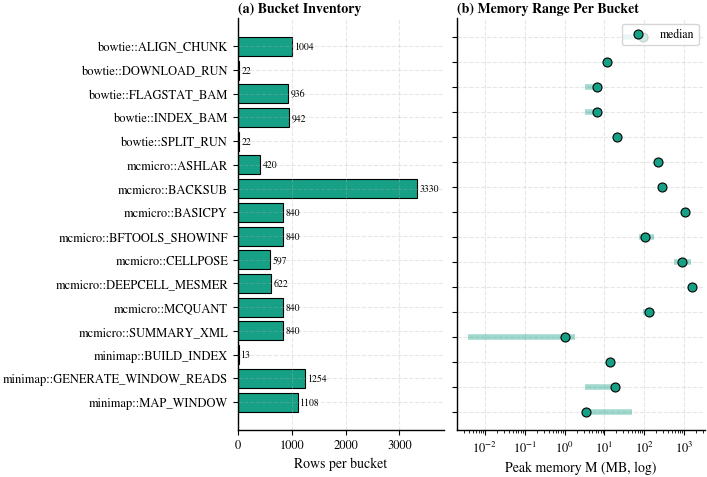

In [4]:
# 80/20 per-bucket split
splits = {}
for (wf, proc), grp in df.groupby(["workflow","process"]):
    if len(grp) < MIN_INSTANCES: continue
    g = grp.sample(frac=1, random_state=SEED).reset_index(drop=True)
    cut = int(len(g) * 0.8)
    splits[(wf, proc)] = (g.iloc[:cut].copy(), g.iloc[cut:].copy())

n_tr_total = sum(len(s[0]) for s in splits.values())
n_te_total = sum(len(s[1]) for s in splits.values())
print(f"train rows: {n_tr_total:,}    test rows: {n_te_total:,}")

# Per-bucket size + memory range — two panels side by side.
# Figure is taller and labels go on the left to give bars room to breathe.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.1, max(3.2, 0.30*len(splits))),
                                 gridspec_kw={"width_ratios":[1, 1.2]},
                                 constrained_layout=True)
def short_bucket(wf, p):
    wfs = {"bowtie2_audit_nf":"bowtie", "minimap2_audit_nf":"minimap"}.get(wf, wf)
    return f"{wfs}::{p}"
labels = [short_bucket(w, p) for (w, p) in splits.keys()]
sizes  = [len(splits[k][0]) + len(splits[k][1]) for k in splits.keys()]
ax1.barh(range(len(labels)), sizes, color="#16a085",
         edgecolor="black", linewidth=0.8)
ax1.set_yticks(range(len(labels))); ax1.set_yticklabels(labels)
ax1.set_xlabel("Rows per bucket")
ax1.set_title("(a) Bucket Inventory", loc="left", pad=4, fontweight="bold"); ax1.invert_yaxis()
ax1.set_xlim(0, max(sizes) * 1.15)
for i, n in enumerate(sizes):
    ax1.text(n + max(sizes)*0.015, i, f"{n}", va="center", fontsize=7)

# Memory range (min, median, max) per bucket on log scale
M_ranges = []
for (wf, proc), (tr, te) in splits.items():
    M_all = pd.concat([tr["M"], te["M"]]).values / 1024**2
    M_ranges.append((np.min(M_all), np.median(M_all), np.max(M_all)))
M_ranges = np.array(M_ranges)
y = np.arange(len(labels))
ax2.hlines(y, M_ranges[:,0], M_ranges[:,2], color="#16a085",
           linewidth=4.0, alpha=0.4)
ax2.scatter(M_ranges[:,1], y, color="#16a085", s=42,
            edgecolor="black", linewidth=0.8, zorder=3, label="median")
ax2.set_xscale("log")
ax2.set_yticks(y); ax2.set_yticklabels([])
ax2.set_xlabel("Peak memory M (MB, log)")
ax2.set_title("(b) Memory Range Per Bucket", loc="left", pad=4, fontweight="bold"); ax2.invert_yaxis()
ax2.legend(loc="upper right", frameon=True)

save_figure(fig, "fig_e2_1_buckets"); plt.show()


## 3. Define probabilistic models

Three model classes, each trained in Sizey (`X = [log a]`) and Joint
(`X = [log a, log c]`) variants:

1. **NGBoost LogNormal** — fits a `LogNormal(mu, sigma)` on raw M; gives
   per-instance mean, std, q50, q95.
2. **Quantile LightGBM** — three independent boosters with the
   `quantile` objective at q={0.05, 0.50, 0.95}; distribution-free spread.
3. **Bayesian Ridge** — closed-form Bayesian linear regression on log M;
   gives Gaussian posterior `(mu, sigma)`.


In [5]:
def mk_ngb():
    return NGBRegressor(Dist=LogNormal, n_estimators=200, learning_rate=0.05,
                        verbose=False, random_state=SEED)

def mk_qlgbm(alpha):
    return LGBMRegressor(objective="quantile", alpha=alpha,
                         n_estimators=200, learning_rate=0.05, num_leaves=31,
                         min_data_in_leaf=2, verbose=-1, random_state=SEED)

def mk_bayesridge():
    return BayesianRidge()

def cv_folds(n, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    chunks = np.array_split(idx, min(k, n))
    for i, te in enumerate(chunks):
        tr = np.concatenate([c for j, c in enumerate(chunks) if j != i])
        if len(tr) and len(te):
            yield tr, te

print("Models defined: NGBoost LogNormal, Quantile LGBM (q05/q50/q95), Bayesian Ridge")


Models defined: NGBoost LogNormal, Quantile LGBM (q05/q50/q95), Bayesian Ridge


## 4. Train every probabilistic model on every bucket

For each bucket we fit:
- NGBoost LogNormal: 1 fit on raw M
- Quantile LGBM: 3 fits at q={0.05, 0.50, 0.95}
- Bayesian Ridge: 1 fit on log M

…in each of the two feature configurations, plus a per-bucket linear-regression
proxy on `[log a, log c, log(c/a)]` for Gate 3. Total: 11 fits per bucket.


In [6]:
trained = {}   # bucket key -> dict with all fitted models + sigmas + proxy
t0 = time.time()
for (wf, proc), (tr_df, te_df) in splits.items():
    a_tr = np.log(tr_df["a"].values + EPS)
    c_tr = np.log(tr_df["c"].values + EPS)
    M_tr_log = np.log(tr_df["M"].values + EPS)

    record = {"wf":wf, "proc":proc,
              "n_tr":len(tr_df), "n_te":len(te_df),
              "fits":{}, "sigmas":{}}

    # ---- Sizey-style and Joint feature matrices ----
    X_tr_s = a_tr.reshape(-1, 1)
    X_tr_j = np.column_stack([a_tr, c_tr])

    # ---- NGBoost LogNormal ----
    for var, X in [("sizey", X_tr_s), ("joint", X_tr_j)]:
        try:
            m = mk_ngb().fit(X, np.exp(M_tr_log))   # NGB LogNormal wants raw M
            record["fits"][f"ngb_{var}"] = m
            # CV sigma in log space
            sig_logs = []
            for ti, _ in cv_folds(len(tr_df)):
                pass  # NGBoost is slow per-fold; rely on LogNormal sigma below
        except Exception as e:
            print(f"  NGB {var} {wf}::{proc} failed: {e}")

    # ---- Quantile LightGBM (q05, q50, q95) ----
    for var, X in [("sizey", X_tr_s), ("joint", X_tr_j)]:
        for q in [0.05, 0.50, 0.95]:
            try:
                m = mk_qlgbm(q).fit(X, M_tr_log)
                record["fits"][f"qlgbm_{var}_q{int(q*100):02d}"] = m
            except Exception as e:
                print(f"  Q-LGBM {var} q={q} {wf}::{proc} failed: {e}")

    # ---- Bayesian Ridge ----
    for var, X in [("sizey", X_tr_s), ("joint", X_tr_j)]:
        try:
            m = mk_bayesridge().fit(X, M_tr_log)
            record["fits"][f"bayesridge_{var}"] = m
        except Exception as e:
            print(f"  BayesRidge {var} {wf}::{proc} failed: {e}")

    # ---- Per-bucket proxy regression for Gate 3 ----
    # log M = b0 + b_a * log a + b_c * log c + b_r * log(c/a)
    # Ridge (small alpha) instead of plain OLS because the three features are
    # linearly dependent: log(c/a) = log c - log a. Ridge spreads weight across
    # the colinear features instead of producing the exploding LR pseudoinverse
    # solution.
    log_ca_ratio_tr = c_tr - a_tr   # log(c/a) = log c - log a
    X_proxy_tr = np.column_stack([a_tr, c_tr, log_ca_ratio_tr])
    proxy = Ridge(alpha=1.0).fit(X_proxy_tr, M_tr_log)
    record["proxy"] = proxy

    trained[(wf, proc)] = record

print(f"\nFitted {len(trained)} buckets in {time.time()-t0:.1f}s")



Fitted 16 buckets in 51.4s


## 4b. Train global fallback models (no bucket structure)

For each probabilistic model class we additionally fit a **single global
predictor on the union of all training rows across all buckets**. This is
the fallback the deployed system uses for buckets that don't yet meet the
$\geq 10$-instance threshold. Reporting per-bucket vs global side by side
lets us answer the per-bucket question of Sizey: does the bucket structure
actually buy us anything, or could a single workflow-global predictor do
the job?

We train: NGBoost LogNormal (Sizey + Joint), Quantile LightGBM at q={0.05,
0.50, 0.95} (Sizey + Joint), and Bayesian Ridge (Sizey + Joint) on the
pooled training rows. Same hyperparameters as the per-bucket fits.


In [7]:
# Pool all per-bucket train splits into a single training set.
all_tr = pd.concat([tr for tr, te in splits.values()], ignore_index=True)
a_all = np.log(all_tr["a"].values + EPS)
c_all = np.log(all_tr["c"].values + EPS)
M_all_log = np.log(all_tr["M"].values + EPS)
print(f"Global training pool: {len(all_tr):,} rows from {len(splits)} buckets")

global_fits = {}

# ---- NGBoost LogNormal (global) ----
for var, X in [("sizey", a_all.reshape(-1,1)),
                ("joint", np.column_stack([a_all, c_all]))]:
    try:
        m = mk_ngb().fit(X, np.exp(M_all_log))
        global_fits[f"ngb_{var}"] = m
    except Exception as e:
        print(f"  global NGB {var} failed: {e}")

# ---- Quantile LightGBM (global) ----
for var, X in [("sizey", a_all.reshape(-1,1)),
                ("joint", np.column_stack([a_all, c_all]))]:
    for q in [0.05, 0.50, 0.95]:
        try:
            m = mk_qlgbm(q).fit(X, M_all_log)
            global_fits[f"qlgbm_{var}_q{int(q*100):02d}"] = m
        except Exception as e:
            print(f"  global Q-LGBM {var} q={q} failed: {e}")

# ---- Bayesian Ridge (global) ----
for var, X in [("sizey", a_all.reshape(-1,1)),
                ("joint", np.column_stack([a_all, c_all]))]:
    try:
        m = mk_bayesridge().fit(X, M_all_log)
        global_fits[f"bayesridge_{var}"] = m
    except Exception as e:
        print(f"  global BayesRidge {var} failed: {e}")

print(f"Global fallback fits: {len(global_fits)}")


Global training pool: 10,899 rows from 16 buckets


Global fallback fits: 10


## 5. Predict on the held-out partition

For each test row we emit:
- `pred_*_MB` — point estimate (mean of the predictive distribution)
- `std_*_MB`  — standard deviation in raw scale (where applicable)
- `q50_*_MB`, `q95_*_MB` — predictive quantiles in raw scale
- `safe_*_MB` — `exp(mu + 1.5 * sigma)` allocation
- `proxy_pred_M_MB`, `proxy_intercept`, `proxy_log_a_coef`, `proxy_log_c_coef`,
  `proxy_log_ca_ratio_coef` — the gate-3 proxy fit


In [8]:
out_rows = []
for (wf, proc), rec in trained.items():
    te_df = splits[(wf, proc)][1]
    a_te = np.log(te_df["a"].values + EPS)
    c_te = np.log(te_df["c"].values + EPS)
    log_ca_ratio_te = c_te - a_te
    M_te = te_df["M"].values

    X_te_s = a_te.reshape(-1, 1)
    X_te_j = np.column_stack([a_te, c_te])
    X_proxy_te = np.column_stack([a_te, c_te, log_ca_ratio_te])

    # ---- NGBoost predictions ----
    ngb_outputs = {}
    for var, X in [("sizey", X_te_s), ("joint", X_te_j)]:
        m = rec["fits"].get(f"ngb_{var}")
        if m is None: continue
        dist = m.pred_dist(X)
        # NGBoost LogNormal is parameterised after scipy.stats.lognorm:
        #   params['s']     = sigma  (shape parameter, == log-space sigma)
        #   params['scale'] = exp(mu)  (so mu_log = log(scale))
        # Mean/var of LogNormal: exp(mu + s2/2), (exp(s2)-1)*exp(2mu + s2)
        try:
            sig_log = np.asarray(dist.params["s"], dtype=float)
            scale   = np.asarray(dist.params["scale"], dtype=float)
            mu_log  = np.log(np.maximum(scale, 1e-9))
        except Exception:
            mu_log  = np.log(np.maximum(dist.mean(), 1.0))
            sig_log = np.full_like(mu_log, 0.5)
        # Clip sigma to keep mean / var finite for very wide posteriors
        sig_log = np.clip(sig_log, 1e-6, 5.0)
        mean_raw = np.exp(mu_log + 0.5 * sig_log**2)
        std_raw  = np.sqrt(np.maximum(np.exp(sig_log**2) - 1.0, 0.0)
                            * np.exp(2 * mu_log + sig_log**2))
        q50_raw  = np.exp(mu_log)                          # LogNormal median = exp(mu)
        q95_raw  = np.exp(mu_log + 1.6448 * sig_log)       # 95th percentile of LogNormal
        safe_raw = np.exp(mu_log + K * sig_log)
        ngb_outputs[var] = dict(mean=mean_raw, std=std_raw,
                                 q50=q50_raw, q95=q95_raw, safe=safe_raw,
                                 mu_log=mu_log, sig_log=sig_log)

    # ---- Quantile LGBM predictions ----
    qlgbm_outputs = {}
    for var, X in [("sizey", X_te_s), ("joint", X_te_j)]:
        out = {}
        for q_int in [5, 50, 95]:
            m = rec["fits"].get(f"qlgbm_{var}_q{q_int:02d}")
            if m is None: continue
            log_pred = m.predict(X)
            out[f"q{q_int:02d}"] = np.exp(log_pred)
        qlgbm_outputs[var] = out

    # ---- Bayesian Ridge predictions ----
    bayes_outputs = {}
    for var, X in [("sizey", X_te_s), ("joint", X_te_j)]:
        m = rec["fits"].get(f"bayesridge_{var}")
        if m is None: continue
        mu_log, sig_log = m.predict(X, return_std=True)
        sig_log = np.clip(sig_log, 1e-6, 1.5)              # cap pathological sigmas
        # Use the *median* (exp(mu_log)) as the point prediction. The LogNormal
        # mean exp(mu + sigma^2/2) is unstable when posterior sigma is large.
        median_raw = np.exp(mu_log)
        # std on raw scale: keep the LogNormal formula but with the clipped sigma.
        std_raw  = np.sqrt(np.maximum(np.exp(sig_log**2) - 1.0, 0.0)
                            * np.exp(2 * mu_log + sig_log**2))
        safe_raw = np.exp(mu_log + K * sig_log)
        bayes_outputs[var] = dict(mean=median_raw, std=std_raw, safe=safe_raw,
                                   mu_log=mu_log, sig_log=sig_log)

    # ---- Proxy regression for Gate 3 ----
    proxy = rec["proxy"]
    proxy_pred_log = proxy.predict(X_proxy_te)
    proxy_pred_raw = np.exp(proxy_pred_log)
    proxy_intercept = float(proxy.intercept_)
    proxy_b_a, proxy_b_c, proxy_b_r = (float(c) for c in proxy.coef_)

    # ---- Global-fallback predictions (NGBoost + Q-LGBM + BayesRidge) ----
    global_outputs = {"ngb": {}, "qlgbm": {}, "bayes": {}}
    for var, X in [("sizey", X_te_s), ("joint", X_te_j)]:
        m = global_fits.get(f"ngb_{var}")
        if m is not None:
            d = m.pred_dist(X)
            # Clip sigma harder for the global predictor — its uncertainty
            # spans the entire workload and the LogNormal mean
            # exp(mu + sigma^2/2) blows up at large sigma. Use the median
            # (exp(mu_log)) as the point estimate, like Bayesian Ridge.
            sg = np.clip(np.asarray(d.params["s"], dtype=float), 1e-6, 2.0)
            mu = np.log(np.maximum(np.asarray(d.params["scale"], dtype=float), 1e-9))
            global_outputs["ngb"][var] = dict(
                mean=np.exp(mu),                  # median (robust)
                std=np.sqrt(np.maximum(np.exp(sg**2)-1.0, 0.0)*np.exp(2*mu+sg**2)),
                q50=np.exp(mu),
                q95=np.exp(mu + 1.6448*sg),
                safe=np.exp(mu + K*sg),
            )
        out = {}
        for q_int in [5, 50, 95]:
            mq = global_fits.get(f"qlgbm_{var}_q{q_int:02d}")
            if mq is None: continue
            out[f"q{q_int:02d}"] = np.exp(mq.predict(X))
        if out: global_outputs["qlgbm"][var] = out
        mb = global_fits.get(f"bayesridge_{var}")
        if mb is not None:
            mu_log_g, sig_log_g = mb.predict(X, return_std=True)
            sig_log_g = np.clip(sig_log_g, 1e-6, 1.5)
            global_outputs["bayes"][var] = dict(
                mean=np.exp(mu_log_g),  # median, robust
                std=np.sqrt(np.maximum(np.exp(sig_log_g**2)-1.0, 0.0)*np.exp(2*mu_log_g+sig_log_g**2)),
                safe=np.exp(mu_log_g + K*sig_log_g),
            )

    # ---- Emit rows ----
    for i, (_, row) in enumerate(te_df.iterrows()):
        rec_out = {
            "workflow":  wf,
            "process":   proc,
            "task_hash": row["task_hash"],
            "a_MB":      row["a"] / 1024**2,
            "c_MB":      row["c"] / 1024**2,
            "M_MB":      row["M"] / 1024**2,
            # NGBoost joint  — primary distributional model the gates will use
            "pred_ngb_joint_MB": (ngb_outputs["joint"]["mean"][i] if "joint" in ngb_outputs else np.nan) / 1024**2,
            "std_ngb_joint_MB":  (ngb_outputs["joint"]["std"][i]  if "joint" in ngb_outputs else np.nan) / 1024**2,
            "q50_ngb_joint_MB":  (ngb_outputs["joint"]["q50"][i]  if "joint" in ngb_outputs else np.nan) / 1024**2,
            "q95_ngb_joint_MB":  (ngb_outputs["joint"]["q95"][i]  if "joint" in ngb_outputs else np.nan) / 1024**2,
            "safe_ngb_joint_MB": (ngb_outputs["joint"]["safe"][i] if "joint" in ngb_outputs else np.nan) / 1024**2,
            # NGBoost sizey
            "pred_ngb_sizey_MB": (ngb_outputs["sizey"]["mean"][i] if "sizey" in ngb_outputs else np.nan) / 1024**2,
            "std_ngb_sizey_MB":  (ngb_outputs["sizey"]["std"][i]  if "sizey" in ngb_outputs else np.nan) / 1024**2,
            "q50_ngb_sizey_MB":  (ngb_outputs["sizey"]["q50"][i]  if "sizey" in ngb_outputs else np.nan) / 1024**2,
            "q95_ngb_sizey_MB":  (ngb_outputs["sizey"]["q95"][i]  if "sizey" in ngb_outputs else np.nan) / 1024**2,
            "safe_ngb_sizey_MB": (ngb_outputs["sizey"]["safe"][i] if "sizey" in ngb_outputs else np.nan) / 1024**2,
            # Quantile LGBM joint
            "qlgbm_joint_q05_MB": (qlgbm_outputs["joint"].get("q05", [np.nan])[i] if "joint" in qlgbm_outputs else np.nan) / 1024**2,
            "qlgbm_joint_q50_MB": (qlgbm_outputs["joint"].get("q50", [np.nan])[i] if "joint" in qlgbm_outputs else np.nan) / 1024**2,
            "qlgbm_joint_q95_MB": (qlgbm_outputs["joint"].get("q95", [np.nan])[i] if "joint" in qlgbm_outputs else np.nan) / 1024**2,
            # Quantile LGBM sizey
            "qlgbm_sizey_q05_MB": (qlgbm_outputs["sizey"].get("q05", [np.nan])[i] if "sizey" in qlgbm_outputs else np.nan) / 1024**2,
            "qlgbm_sizey_q50_MB": (qlgbm_outputs["sizey"].get("q50", [np.nan])[i] if "sizey" in qlgbm_outputs else np.nan) / 1024**2,
            "qlgbm_sizey_q95_MB": (qlgbm_outputs["sizey"].get("q95", [np.nan])[i] if "sizey" in qlgbm_outputs else np.nan) / 1024**2,
            # Bayesian Ridge
            "pred_bayesridge_joint_MB": (bayes_outputs["joint"]["mean"][i] if "joint" in bayes_outputs else np.nan) / 1024**2,
            "std_bayesridge_joint_MB":  (bayes_outputs["joint"]["std"][i]  if "joint" in bayes_outputs else np.nan) / 1024**2,
            "safe_bayesridge_joint_MB": (bayes_outputs["joint"]["safe"][i] if "joint" in bayes_outputs else np.nan) / 1024**2,
            "pred_bayesridge_sizey_MB": (bayes_outputs["sizey"]["mean"][i] if "sizey" in bayes_outputs else np.nan) / 1024**2,
            "std_bayesridge_sizey_MB":  (bayes_outputs["sizey"]["std"][i]  if "sizey" in bayes_outputs else np.nan) / 1024**2,
            "safe_bayesridge_sizey_MB": (bayes_outputs["sizey"]["safe"][i] if "sizey" in bayes_outputs else np.nan) / 1024**2,
            # Per-bucket proxy regression (Gate-3 reference)
            "proxy_pred_M_MB":         proxy_pred_raw[i] / 1024**2,
            "proxy_intercept":          proxy_intercept,
            "proxy_log_a_coef":         proxy_b_a,
            "proxy_log_c_coef":         proxy_b_c,
            "proxy_log_ca_ratio_coef":  proxy_b_r,
            # Global fallback (one model trained on all rows across all buckets)
            "pred_ngb_global_joint_MB":  (global_outputs["ngb"]["joint"]["mean"][i] if "joint" in global_outputs["ngb"] else np.nan) / 1024**2,
            "std_ngb_global_joint_MB":   (global_outputs["ngb"]["joint"]["std"][i]  if "joint" in global_outputs["ngb"] else np.nan) / 1024**2,
            "q50_ngb_global_joint_MB":   (global_outputs["ngb"]["joint"]["q50"][i]  if "joint" in global_outputs["ngb"] else np.nan) / 1024**2,
            "q95_ngb_global_joint_MB":   (global_outputs["ngb"]["joint"]["q95"][i]  if "joint" in global_outputs["ngb"] else np.nan) / 1024**2,
            "safe_ngb_global_joint_MB":  (global_outputs["ngb"]["joint"]["safe"][i] if "joint" in global_outputs["ngb"] else np.nan) / 1024**2,
            "pred_ngb_global_sizey_MB":  (global_outputs["ngb"]["sizey"]["mean"][i] if "sizey" in global_outputs["ngb"] else np.nan) / 1024**2,
            "std_ngb_global_sizey_MB":   (global_outputs["ngb"]["sizey"]["std"][i]  if "sizey" in global_outputs["ngb"] else np.nan) / 1024**2,
            "q50_ngb_global_sizey_MB":   (global_outputs["ngb"]["sizey"]["q50"][i]  if "sizey" in global_outputs["ngb"] else np.nan) / 1024**2,
            "q95_ngb_global_sizey_MB":   (global_outputs["ngb"]["sizey"]["q95"][i]  if "sizey" in global_outputs["ngb"] else np.nan) / 1024**2,
            "safe_ngb_global_sizey_MB":  (global_outputs["ngb"]["sizey"]["safe"][i] if "sizey" in global_outputs["ngb"] else np.nan) / 1024**2,
            "qlgbm_global_joint_q50_MB": (global_outputs["qlgbm"]["joint"].get("q50", [np.nan])[i] if "joint" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "qlgbm_global_joint_q05_MB": (global_outputs["qlgbm"]["joint"].get("q05", [np.nan])[i] if "joint" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "qlgbm_global_joint_q95_MB": (global_outputs["qlgbm"]["joint"].get("q95", [np.nan])[i] if "joint" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "qlgbm_global_sizey_q50_MB": (global_outputs["qlgbm"]["sizey"].get("q50", [np.nan])[i] if "sizey" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "qlgbm_global_sizey_q05_MB": (global_outputs["qlgbm"]["sizey"].get("q05", [np.nan])[i] if "sizey" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "qlgbm_global_sizey_q95_MB": (global_outputs["qlgbm"]["sizey"].get("q95", [np.nan])[i] if "sizey" in global_outputs["qlgbm"] else np.nan) / 1024**2,
            "pred_bayesridge_global_joint_MB": (global_outputs["bayes"]["joint"]["mean"][i] if "joint" in global_outputs["bayes"] else np.nan) / 1024**2,
            "std_bayesridge_global_joint_MB":  (global_outputs["bayes"]["joint"]["std"][i]  if "joint" in global_outputs["bayes"] else np.nan) / 1024**2,
            "safe_bayesridge_global_joint_MB": (global_outputs["bayes"]["joint"]["safe"][i] if "joint" in global_outputs["bayes"] else np.nan) / 1024**2,
            "pred_bayesridge_global_sizey_MB": (global_outputs["bayes"]["sizey"]["mean"][i] if "sizey" in global_outputs["bayes"] else np.nan) / 1024**2,
            "std_bayesridge_global_sizey_MB":  (global_outputs["bayes"]["sizey"]["std"][i]  if "sizey" in global_outputs["bayes"] else np.nan) / 1024**2,
            "safe_bayesridge_global_sizey_MB": (global_outputs["bayes"]["sizey"]["safe"][i] if "sizey" in global_outputs["bayes"] else np.nan) / 1024**2,
        }
        out_rows.append(rec_out)

pred_df = pd.DataFrame(out_rows)
pred_df.to_csv(OUT/"predictions_exp2.csv", index=False)
print(f"\nWrote {OUT/'predictions_exp2.csv'} ({len(pred_df):,} rows, {len(pred_df.columns)} cols)")
pred_df.head()



Wrote C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\experiment_2\predictions_exp2.csv (2,731 rows, 55 cols)


,workflow,process,task_hash,a_MB,c_MB,M_MB,pred_ngb_joint_MB,std_ngb_joint_MB,q50_ngb_joint_MB,q95_ngb_joint_MB,...,qlgbm_global_joint_q95_MB,qlgbm_global_sizey_q50_MB,qlgbm_global_sizey_q05_MB,qlgbm_global_sizey_q95_MB,pred_bayesridge_global_joint_MB,std_bayesridge_global_joint_MB,safe_bayesridge_global_joint_MB,pred_bayesridge_global_sizey_MB,std_bayesridge_global_sizey_MB,safe_bayesridge_global_sizey_MB
0,bowtie2_audit_nf,ALIGN_CHUNK,d974ff66f659c450466ff7337d9fa55a,62.9,51.323683,96.0,95.471355,1.537508,95.458977,98.021161,...,98.396973,95.200957,91.740818,98.090231,101.563259,143.606603,354.038967,112.745043,160.392776,394.459983
1,bowtie2_audit_nf,ALIGN_CHUNK,8c4dbaf6e48889b8405a056f9758d162,62.0,50.679137,96.4,95.186426,1.477228,95.174966,97.635540,...,97.983524,95.202466,91.648009,98.255682,100.022222,141.424946,348.663091,111.067378,158.003890,388.587082
2,bowtie2_audit_nf,ALIGN_CHUNK,f482df1877d62eb830eb2374c409c4ed,63.6,52.105268,95.2,95.450111,1.274511,95.441603,97.560824,...,98.687396,95.403382,91.740818,98.460221,102.879041,145.472030,358.632992,114.050562,162.251776,399.030173
3,bowtie2_audit_nf,ALIGN_CHUNK,90cbeceaa7cb6a278984d8ec1712376c,64.1,52.949033,92.8,94.829119,1.309107,94.820085,96.997624,...,98.687396,95.200117,91.744681,98.080472,103.936954,146.974331,362.330319,114.983431,163.580151,402.295855
4,bowtie2_audit_nf,ALIGN_CHUNK,cc9de65afdce0048c5533dec62b6d20f,63.5,51.807952,92.9,94.622678,1.623575,94.608752,97.316647,...,98.396973,95.403382,91.740818,98.460221,102.614234,145.095017,357.706073,113.864024,161.986153,398.377162


## 6. Held-out prediction quality per probabilistic model

Same five metrics as Experiment 1 (MAPE, R²_log, coverage at factor 2,
wastage in GB-h, OOM count) but evaluated on the **mean** of each
predictive distribution. The probabilistic models are also evaluated for
**calibration** of their tail (q95 coverage rate).

In [9]:
def mape(p, M): return float(np.mean(np.abs(p - M) / M) * 100)
def r2_log(p, M):
    log_p = np.log(p + EPS); log_M = np.log(M + EPS)
    ss_res = np.sum((log_M - log_p)**2)
    ss_tot = np.sum((log_M - log_M.mean())**2)
    return float(1 - ss_res/ss_tot) if ss_tot > 0 else float("nan")
def cov2x(p, M): return float(np.mean((p >= 0.5*M) & (p <= 2.0*M)) * 100)

# Build prediction-vs-actual columns for each probabilistic mean
columns_to_eval = [
    ("ngb_sizey",                   "pred_ngb_sizey_MB"),
    ("ngb_joint",                   "pred_ngb_joint_MB"),
    ("ngb_global_sizey",            "pred_ngb_global_sizey_MB"),
    ("ngb_global_joint",            "pred_ngb_global_joint_MB"),
    ("qlgbm_sizey",                 "qlgbm_sizey_q50_MB"),
    ("qlgbm_joint",                 "qlgbm_joint_q50_MB"),
    ("qlgbm_global_sizey",          "qlgbm_global_sizey_q50_MB"),
    ("qlgbm_global_joint",          "qlgbm_global_joint_q50_MB"),
    ("bayesridge_sizey",            "pred_bayesridge_sizey_MB"),
    ("bayesridge_joint",            "pred_bayesridge_joint_MB"),
    ("bayesridge_global_sizey",     "pred_bayesridge_global_sizey_MB"),
    ("bayesridge_global_joint",     "pred_bayesridge_global_joint_MB"),
]

rows = []
M_act = pred_df["M_MB"].values
for label, col in columns_to_eval:
    p = pred_df[col].values
    mask = ~np.isnan(p)
    rows.append({
        "model":  label,
        "n":      int(mask.sum()),
        "MAPE":   round(mape(p[mask], M_act[mask]), 2),
        "R2_log": round(r2_log(p[mask], M_act[mask]), 3),
        "cov2x":  round(cov2x(p[mask], M_act[mask]), 1),
    })
metrics = pd.DataFrame(rows)
print(metrics.to_string(index=False))

# Tail-calibration: for each model with a q95, fraction of M actually below q95
print("\nTail calibration (q95 should cover ~95% of actuals):")
for var in ["sizey", "joint"]:
    for label, q_col in [("NGBoost", f"q95_ngb_{var}_MB"), ("Q-LGBM", f"qlgbm_{var}_q95_MB")]:
        mask = ~pred_df[q_col].isna()
        cov95 = float(np.mean(pred_df.loc[mask, q_col].values >= pred_df.loc[mask, "M_MB"].values) * 100)
        print(f"  {label:<8} {var:<6} q95 covers {cov95:.1f}% of actuals")


                  model    n   MAPE  R2_log  cov2x
              ngb_sizey 2731  30.77   0.966   93.1
              ngb_joint 2731  22.43   0.970   91.4
       ngb_global_sizey 2731  32.42   0.964   89.3
       ngb_global_joint 2731  19.30   0.972   90.4
            qlgbm_sizey 2731  16.12   0.944   92.1
            qlgbm_joint 2731  17.60   0.956   93.4
     qlgbm_global_sizey 2731  42.27   0.927   91.4
     qlgbm_global_joint 2731  20.58   0.956   93.2
       bayesridge_sizey 2731  22.68   0.969   89.7
       bayesridge_joint 2731  22.52   0.970   90.4
bayesridge_global_sizey 2731 103.61   0.843   60.9
bayesridge_global_joint 2731  97.68   0.847   68.1

Tail calibration (q95 should cover ~95% of actuals):
  NGBoost  sizey  q95 covers 96.7% of actuals
  Q-LGBM   sizey  q95 covers 85.9% of actuals
  NGBoost  joint  q95 covers 90.7% of actuals
  Q-LGBM   joint  q95 covers 81.8% of actuals


## 7. FIGURE — Three metrics side-by-side: MAPE, R²_log, Cov 2×

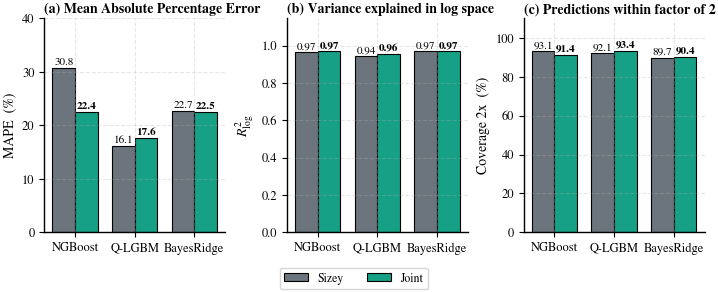

In [10]:
colors = {"sizey":"#6c757d", "joint":"#16a085"}
order  = ["ngb", "qlgbm", "bayesridge"]
labels = ["NGBoost", "Q-LGBM", "BayesRidge"]

fig, axes = plt.subplots(1, 3, figsize=(7.1, 2.6), constrained_layout=True)
for ax, key, ylab, title in zip(
    axes,
    ["MAPE", "R2_log", "cov2x"],
    ["MAPE  (%)", r"$R^2_{\log}$", "Coverage 2x  (%)"],
    ["(a) Mean Absolute Percentage Error",
     "(b) Variance explained in log space",
     "(c) Predictions within factor of 2"],
):
    sizey_vals = [metrics[metrics.model==f"{m}_sizey"][key].iloc[0] for m in order]
    joint_vals = [metrics[metrics.model==f"{m}_joint"][key].iloc[0] for m in order]
    x = np.arange(len(order)); w = 0.38
    b1 = ax.bar(x-w/2, sizey_vals, w, label="Sizey", color=colors["sizey"],
                edgecolor="black", linewidth=0.8)
    b2 = ax.bar(x+w/2, joint_vals, w, label="Joint", color=colors["joint"],
                edgecolor="black", linewidth=0.8)
    # Headroom so legend never overlaps tallest bar
    ymax = max([v for v in sizey_vals + joint_vals if np.isfinite(v)] + [0])
    if key == "R2_log":
        ax.set_ylim(0, max(1.0, ymax*1.18))
    elif key == "cov2x":
        ax.set_ylim(0, 110)
    else:
        ax.set_ylim(0, ymax * 1.30)
    fmt = "{:.2f}" if key=="R2_log" else "{:.1f}"
    for b, v in zip(b1, sizey_vals):
        if not np.isfinite(v): continue
        ax.text(b.get_x()+b.get_width()/2, v + ymax*0.02 if key!="R2_log" else v + 0.015,
                fmt.format(v), ha="center", fontsize=8)
    for b, v in zip(b2, joint_vals):
        if not np.isfinite(v): continue
        ax.text(b.get_x()+b.get_width()/2, v + ymax*0.02 if key!="R2_log" else v + 0.015,
                fmt.format(v), ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel(ylab); ax.set_title(title, loc="left", pad=4, fontweight="bold")
# One legend for the whole figure, placed below the panels.
handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc="lower center", ncol=2, frameon=True,
           bbox_to_anchor=(0.5, -0.14))
save_figure(fig, "fig_e2_2_metrics"); plt.show()


## 8. FIGURE — Reliability diagram (the key calibration figure for the gates)

For a well-calibrated probabilistic model, the empirical fraction of test
actuals falling below the predicted q-th quantile should be approximately q.
We compute this at q ∈ {0.05, 0.10, ..., 0.95} for every probabilistic
model and plot empirical vs nominal.  Models close to the diagonal are
calibrated; G2 (tail-risk gate) only works correctly on calibrated
distributions because it queries P(M > capacity) directly from the
predictive CDF.


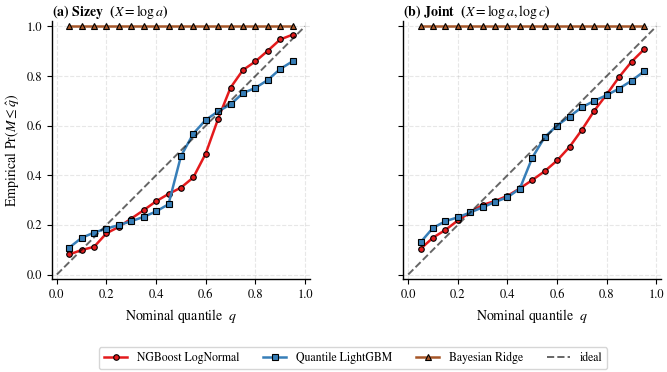

In [11]:
nominals = np.linspace(0.05, 0.95, 19)
fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.3), sharey=True,
                           constrained_layout=True)

def empirical_coverage_lognormal(mu_log, sig_log, M_actual, q):
    """For a LogNormal with given (mu, sigma) per-row, fraction of M below q-th quantile."""
    z = norm.ppf(q)
    pred_q = np.exp(mu_log + z * sig_log)
    return float(np.mean(M_actual <= pred_q))

def empirical_coverage_quantile(qcol_template, df, M_actual, q):
    """Use existing q05/q50/q95 columns; linearly interpolate in q-space."""
    avail_q = [0.05, 0.50, 0.95]
    cols = [qcol_template.format(int(av*100)) for av in avail_q]
    qvals = df[cols].values
    if q <= 0.05: pred_q = qvals[:,0]
    elif q >= 0.95: pred_q = qvals[:,2]
    elif q <= 0.5:
        w = (q - 0.05) / (0.5 - 0.05)
        pred_q = qvals[:,0]*(1-w) + qvals[:,1]*w
    else:
        w = (q - 0.5) / (0.95 - 0.5)
        pred_q = qvals[:,1]*(1-w) + qvals[:,2]*w
    return float(np.mean(M_actual <= pred_q))

# Recover per-row mu_log, sig_log from the trained NGBoost models — easier than
# inverting the columns we wrote.
ngb_mu_log = {}
ngb_sig_log = {}
for var in ["sizey", "joint"]:
    mus, sigs = [], []
    for (wf, proc), rec in trained.items():
        te_df = splits[(wf, proc)][1]
        a_te = np.log(te_df["a"].values + EPS)
        c_te = np.log(te_df["c"].values + EPS)
        X = a_te.reshape(-1,1) if var=="sizey" else np.column_stack([a_te, c_te])
        m = rec["fits"].get(f"ngb_{var}")
        d = m.pred_dist(X)
        sig_log = np.clip(np.asarray(d.params["s"], dtype=float), 1e-6, 5.0)
        mu_log  = np.log(np.maximum(np.asarray(d.params["scale"], dtype=float), 1e-9))
        mus.append(mu_log); sigs.append(sig_log)
    ngb_mu_log[var]  = np.concatenate(mus)
    ngb_sig_log[var] = np.concatenate(sigs)

M_act = pred_df["M_MB"].values * 1024**2  # back to bytes for consistency with mu_log

for ax, var, title in zip(axes, ["sizey", "joint"],
                           [r"(a) Sizey  ($X = \log a$)",
                            r"(b) Joint  ($X = \log a, \log c$)"]):
    # NGBoost LogNormal — analytic
    cov_ngb = [empirical_coverage_lognormal(ngb_mu_log[var], ngb_sig_log[var],
                                              M_act, q) for q in nominals]
    ax.plot(nominals, cov_ngb, "-o", color="#e41a1c", lw=1.8, markersize=4.0,
             markeredgecolor="black", markeredgewidth=0.8, label="NGBoost LogNormal")
    # Q-LGBM — interpolated from q05/q50/q95
    qcol = f"qlgbm_{var}_q{{:02d}}_MB"
    M_act_MB = pred_df["M_MB"].values
    cov_q = [empirical_coverage_quantile(qcol, pred_df, M_act_MB, q) for q in nominals]
    ax.plot(nominals, cov_q, "-s", color="#377eb8", lw=1.8, markersize=4.0,
             markeredgecolor="black", markeredgewidth=0.8, label="Quantile LightGBM")
    # Bayesian Ridge — Gaussian on log M
    fits = []
    for (wf, proc), rec in trained.items():
        te_df = splits[(wf, proc)][1]
        a_te = np.log(te_df["a"].values + EPS)
        c_te = np.log(te_df["c"].values + EPS)
        X = a_te.reshape(-1,1) if var=="sizey" else np.column_stack([a_te, c_te])
        m = rec["fits"].get(f"bayesridge_{var}")
        mu, sig = m.predict(X, return_std=True)
        fits.append((mu, np.clip(sig, 1e-6, 1.5)))
    mu_b  = np.concatenate([f[0] for f in fits])
    sig_b = np.concatenate([f[1] for f in fits])
    cov_b = [float(np.mean(np.log(M_act_MB) <= mu_b + norm.ppf(q)*sig_b))
             for q in nominals]
    ax.plot(nominals, cov_b, "-^", color="#a65628", lw=1.8, markersize=4.0,
             markeredgecolor="black", markeredgewidth=0.8, label="Bayesian Ridge")

    ax.plot([0,1], [0,1], "k--", lw=1.4, alpha=0.6, label="ideal")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Nominal quantile  $q$")
    if var == "sizey": ax.set_ylabel(r"Empirical $\Pr(M \leq \hat q)$")
    ax.set_title(title, loc="left", pad=4, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")

# Single legend below both panels, no overlap with the diagonal.
handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc="lower center", ncol=4, frameon=True,
           bbox_to_anchor=(0.5, -0.14))
save_figure(fig, "fig_e2_3_reliability"); plt.show()


## 9. FIGURE — Sharpness vs coverage (the tradeoff plot)

A probabilistic model is *sharp* if its prediction intervals are narrow,
and *calibrated* if the empirical coverage matches the nominal level. We
want both. For each model and each nominal coverage level we plot
(coverage, mean interval width). Closer to the top-left corner is better
(narrow intervals at high coverage). Joint models should sit to the
upper-left of their Sizey counterparts.


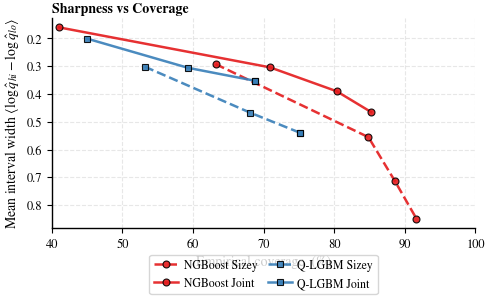

In [12]:
nominals_band = [0.50, 0.80, 0.90, 0.95]
fig, ax = plt.subplots(figsize=(4.9, 3.0), constrained_layout=True)

def lognormal_band(mu_log, sig_log, q):
    """Return (q_low, q_high) for central interval of given probability mass q."""
    z = norm.ppf((1 + q) / 2)
    lo = np.exp(mu_log - z * sig_log)
    hi = np.exp(mu_log + z * sig_log)
    return lo, hi

M_act_MB = pred_df["M_MB"].values
M_act_bytes = M_act_MB * 1024**2

# Bayesian Ridge is retained in the metric tables, but omitted from this main
# sharpness figure because its very wide log-Gaussian intervals dominate the
# y-scale and hide the comparison between the two stronger probabilistic models.
for label, color, marker, ls in [
    ("NGBoost Sizey",       "#e41a1c", "o", "--"),
    ("NGBoost Joint",       "#e41a1c", "o", "-"),
    ("Q-LGBM Sizey",        "#377eb8", "s", "--"),
    ("Q-LGBM Joint",        "#377eb8", "s", "-"),
]:
    var = "sizey" if "Sizey" in label else "joint"
    coverages, widths = [], []
    for q in nominals_band:
        if "NGBoost" in label:
            lo, hi = lognormal_band(ngb_mu_log[var], ngb_sig_log[var], q)
            lo_MB = lo / 1024**2; hi_MB = hi / 1024**2
        elif "Q-LGBM" in label:
            # Use q05/q50/q95 to construct symmetric central bands by interpolation
            ql, qh = (1-q)/2, (1+q)/2
            qcol = f"qlgbm_{var}_q{{:02d}}_MB"
            def interp(qq):
                if qq <= 0.05: return pred_df[qcol.format(5)].values
                if qq >= 0.95: return pred_df[qcol.format(95)].values
                if qq <= 0.5:
                    w = (qq - 0.05)/(0.5 - 0.05)
                    return pred_df[qcol.format(5)].values*(1-w) + pred_df[qcol.format(50)].values*w
                w = (qq - 0.5)/(0.95 - 0.5)
                return pred_df[qcol.format(50)].values*(1-w) + pred_df[qcol.format(95)].values*w
            lo_MB, hi_MB = interp(ql), interp(qh)
        cov  = float(np.mean((M_act_MB >= lo_MB) & (M_act_MB <= hi_MB)))
        # Use *log-space* width because raw-byte widths are huge and uneven
        log_w = float(np.mean(np.log(np.maximum(hi_MB, 1e-3)) - np.log(np.maximum(lo_MB, 1e-3))))
        coverages.append(cov*100); widths.append(log_w)
    ax.plot(coverages, widths, ls, color=color, marker=marker, markersize=5,
             markeredgecolor="black", markeredgewidth=0.8, lw=1.8, label=label, alpha=0.9)

# Annotate each marker with its nominal q
ax.set_xlabel("Empirical coverage  (%)")
ax.set_ylabel(r"Mean interval width $\langle \log \hat q_{hi} - \log \hat q_{lo}\rangle$")
ax.set_title("Sharpness vs Coverage", loc="left", pad=4, fontweight="bold")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.34), frameon=True,
          ncol=2, columnspacing=0.9, handletextpad=0.5)
ax.set_xlim(40, 100); ax.invert_yaxis()
save_figure(fig, "fig_e2_4_sharpness"); plt.show()


## 10. FIGURE — Per-bucket NGBoost MAPE breakdown (Sizey vs Joint)

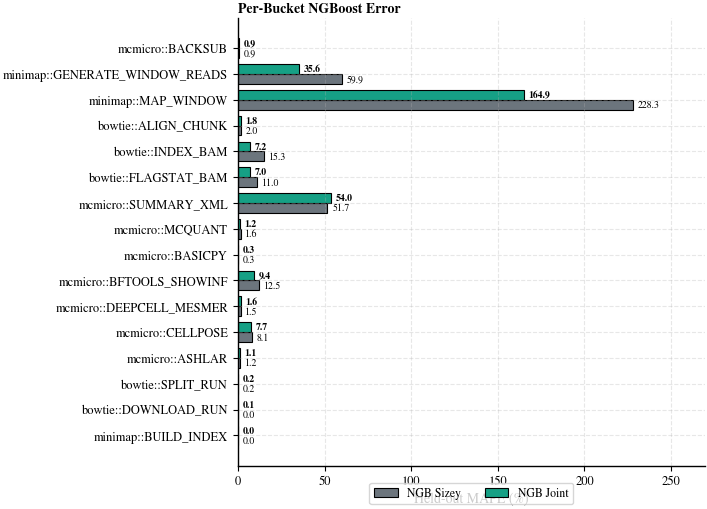

,bucket,n_te,ngb_sizey_MAPE,ngb_joint_MAPE,short
13,minimap2_audit_nf::BUILD_INDEX,3,0.000007,0.000007,minimap::BUILD_INDEX
1,bowtie2_audit_nf::DOWNLOAD_RUN,5,0.000008,0.074907,bowtie::DOWNLOAD_RUN
4,bowtie2_audit_nf::SPLIT_RUN,5,0.200028,0.180271,bowtie::SPLIT_RUN
5,mcmicro::ASHLAR,84,1.154174,1.135950,mcmicro::ASHLAR
9,mcmicro::CELLPOSE,120,8.125651,7.744653,mcmicro::CELLPOSE
10,mcmicro::DEEPCELL_MESMER,125,1.548053,1.602735,mcmicro::DEEPCELL_MESMER
8,mcmicro::BFTOOLS_SHOWINF,168,12.487798,9.385252,mcmicro::BFTOOLS_SHOWINF
7,mcmicro::BASICPY,168,0.294680,0.287609,mcmicro::BASICPY
11,mcmicro::MCQUANT,168,1.558277,1.179169,mcmicro::MCQUANT
12,mcmicro::SUMMARY_XML,168,51.694190,53.995033,mcmicro::SUMMARY_XML


In [13]:
bucket_rows = []
for (wf, proc), (tr_df, te_df) in splits.items():
    sub = pred_df[(pred_df.workflow == wf) & (pred_df.process == proc)]
    if len(sub) == 0: continue
    M = sub["M_MB"].values
    row = {"bucket": f"{wf}::{proc}", "n_te": len(sub)}
    for var in ["sizey", "joint"]:
        p = sub[f"pred_ngb_{var}_MB"].values
        m = ~np.isnan(p)
        row[f"ngb_{var}_MAPE"] = mape(p[m], M[m]) if m.any() else np.nan
    bucket_rows.append(row)
bdf = pd.DataFrame(bucket_rows).sort_values("n_te", ascending=True)
# Shorten workflow names for the y-axis so labels fit
def short_b(s):
    s = s.replace("bowtie2_audit_nf", "bowtie")
    s = s.replace("minimap2_audit_nf", "minimap")
    return s
bdf["short"] = bdf.bucket.apply(short_b)

fig, ax = plt.subplots(figsize=(7.1, max(3.2, 0.32*len(bdf))), constrained_layout=True)
y = np.arange(len(bdf)); h = 0.38
ax.barh(y - h/2, bdf.ngb_sizey_MAPE, h, color=colors["sizey"],
        edgecolor="black", linewidth=0.8, label="NGB Sizey")
ax.barh(y + h/2, bdf.ngb_joint_MAPE, h, color=colors["joint"],
        edgecolor="black", linewidth=0.8, label="NGB Joint")
xmax = max([v for v in list(bdf.ngb_sizey_MAPE) + list(bdf.ngb_joint_MAPE) if np.isfinite(v)] + [0])
for i, (s, j) in enumerate(zip(bdf.ngb_sizey_MAPE, bdf.ngb_joint_MAPE)):
    if np.isfinite(s):
        ax.text(s + xmax*0.012, i - h/2, f"{s:.1f}", va="center", fontsize=7)
    if np.isfinite(j):
        ax.text(j + xmax*0.012, i + h/2, f"{j:.1f}", va="center",
                fontsize=7, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(bdf.short)
ax.set_xlim(0, xmax * 1.18)
ax.set_xlabel("Held-out MAPE (%)")
ax.set_title("Per-Bucket NGBoost Error", loc="left", pad=4, fontweight="bold")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=True)
save_figure(fig, "fig_e2_5_per_bucket_mape"); plt.show()
bdf


## 11. FIGURE — PIT histogram (probabilistic calibration in one picture)

The Probability Integral Transform of a sample is `F(M_actual)` where F is
the predictive CDF. If the model is calibrated, the PIT values are
uniformly distributed on `[0, 1]`. A U-shaped histogram means the
predictive distribution is too narrow (mass beyond the tails); an
arch-shaped histogram means it is too wide. This is the gold-standard
calibration check for probabilistic regression.


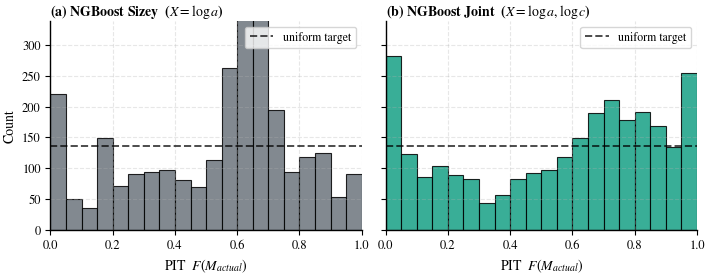

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.8), sharey=True,
                           constrained_layout=True)
M_act_MB = pred_df["M_MB"].values
for ax, var, title in zip(axes, ["sizey", "joint"],
                           [r"(a) NGBoost Sizey  ($X{=}\log a$)",
                            r"(b) NGBoost Joint  ($X{=}\log a, \log c$)"]):
    # PIT under LogNormal: F(M) = Phi((log M - mu_log) / sig_log)
    z = (np.log(M_act_MB * 1024**2) - ngb_mu_log[var]) / ngb_sig_log[var]
    pit = norm.cdf(z)
    counts, _, _ = ax.hist(pit, bins=20, range=(0, 1),
            color=colors["sizey"] if var == "sizey" else colors["joint"],
            edgecolor="black", linewidth=0.8, alpha=0.85)
    ax.axhline(len(pit)/20, color="black", linestyle="--", linewidth=1.4, alpha=0.7,
               label="uniform target")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(counts) * 1.20)        # headroom for legend
    ax.set_xlabel("PIT  $F(M_{actual})$")
    if var == "sizey": ax.set_ylabel("Count")
    ax.set_title(title, loc="left", pad=4, fontweight="bold")
    ax.legend(loc="upper right", frameon=True, bbox_to_anchor=(1.0, 1.0))
save_figure(fig, "fig_e2_6_pit"); plt.show()


## 12. FIGURE — Predictive distributions at four representative test rows

This is what NGBoost-Joint actually outputs to the gate at deployment.
For each of four sample test rows we plot:

* the predictive PDF as a filled green area
* the **OOM-risk region** (PDF mass above capacity) shaded in red
* the predictive CDF on the right-hand axis
* the predicted q05, q50, q95 as vertical markers
* the *actual* peak memory observed for that task as a solid red line
* the capacity threshold (90th percentile of the bucket's training memory) as a dashed black line

The four rows are chosen by predictive sigma rank: very confident,
moderately confident, moderately uncertain, very uncertain. Gate 2 is
exactly the red-shaded area: `P(M > capacity)`. The picture makes the
gate's input concrete.


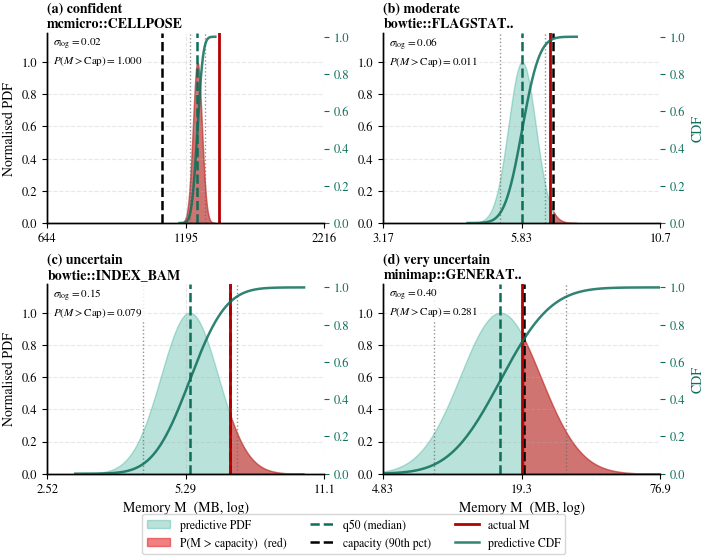

In [15]:
sigs_joint = ngb_sig_log["joint"]

def nearest_sigma_pick(target, used):
    order = np.argsort(np.abs(sigs_joint - target))
    for idx in order:
        if int(idx) not in used:
            used.add(int(idx))
            return int(idx)
    raise RuntimeError("could not find unique sigma pick")

# Avoid the near-degenerate sigma≈0 examples because they collapse into
# unreadable vertical spikes in the paper. These target sigmas still span the
# uncertainty range while remaining visually interpretable.
used = set()
targets = [0.02, 0.06, 0.15, 0.40]
picks = [nearest_sigma_pick(t, used) for t in targets]
labels_uncertainty = ["confident", "moderate", "uncertain", "very uncertain"]

fig, axes = plt.subplots(2, 2, figsize=(7.1, 5.2), sharey=False,
                           constrained_layout=True)
axes = axes.ravel()
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, idx, ulabel, panel in zip(axes, picks, labels_uncertainty, panel_labels):
    mu, sg = ngb_mu_log["joint"][idx], ngb_sig_log["joint"][idx]
    M_true_bytes = pred_df["M_MB"].values[idx] * 1024**2
    wf  = pred_df["workflow"].values[idx]
    prc = pred_df["process"].values[idx]
    bucket = f"{wf}::{prc}"

    # Capacity = 90th-pct of this bucket's M (held-out)
    sub = pred_df[(pred_df.workflow == wf) & (pred_df.process == prc)]
    cap_bytes = np.percentile(sub["M_MB"].values, 90) * 1024**2

    # PDF/CDF grid in log-bytes
    log_x = np.linspace(mu - 4*sg, mu + 4*sg, 600)
    x_MB  = np.exp(log_x) / 1024**2
    pdf   = norm.pdf((log_x - mu) / sg) / sg
    pdf_n = pdf / pdf.max()
    cdf   = norm.cdf((log_x - mu) / sg)

    # Quantiles
    q05 = np.exp(mu + norm.ppf(0.05) * sg) / 1024**2
    q50 = np.exp(mu) / 1024**2
    q95 = np.exp(mu + norm.ppf(0.95) * sg) / 1024**2

    # P(M > capacity) under the predictive
    p_oom = 1.0 - norm.cdf((np.log(cap_bytes) - mu) / sg)
    cap_MB = cap_bytes / 1024**2
    M_true_MB = M_true_bytes / 1024**2

    # ---- PDF (left axis, filled) ----
    pdf_handle = ax.fill_between(x_MB, 0, pdf_n,
                                  color="#16a085", alpha=0.30,
                                  label="predictive PDF")
    # OOM-risk region (PDF mass above capacity)
    risk_handle = None
    risk_mask = x_MB >= cap_MB
    if risk_mask.any():
        risk_handle = ax.fill_between(x_MB[risk_mask], 0, pdf_n[risk_mask],
                                       color="#e41a1c", alpha=0.55,
                                       label="P(M>cap)")

    # Quantile markers (no labels — annotated separately to avoid legend clutter)
    ax.axvline(q05, color="#666666", lw=1.0, linestyle=":", alpha=0.7)
    q50_handle = ax.axvline(q50, color="#0d6e5a", lw=1.8, linestyle="--",
                              label="q50")
    ax.axvline(q95, color="#666666", lw=1.0, linestyle=":", alpha=0.7)

    cap_handle = ax.axvline(cap_MB, color="black", lw=1.8, linestyle="--",
                              label="capacity")
    actual_handle = ax.axvline(M_true_MB, color="#b30000", lw=2.0, linestyle="-",
                                 label="actual M")

    # ---- CDF on twin axis (right) ----
    axR = ax.twinx()
    cdf_handle, = axR.plot(x_MB, cdf, color="#0d6e5a", lw=1.8, alpha=0.85,
                             label="predictive CDF")
    axR.set_ylim(0, 1.02)
    if panel in ["(b)", "(d)"]:
        axR.set_ylabel("CDF", color="#0d6e5a")
    axR.tick_params(axis="y", colors="#0d6e5a")
    axR.spines["right"].set_color("#0d6e5a")
    axR.spines["top"].set_visible(False)
    axR.grid(False)

    # X range chosen so all key markers (cap, actual, predictive support) fit
    xmin = min(q05 * 0.6, M_true_MB * 0.6, cap_MB * 0.6)
    xmax = max(q95 * 1.6, M_true_MB * 1.6, cap_MB * 1.6, x_MB.max())
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    xticks = np.geomspace(xmin, xmax, 3)
    ax.set_xticks(xticks)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(format_mb_tick))
    ax.set_ylim(0, 1.18)
    if panel in ["(c)", "(d)"]:
        ax.set_xlabel("Memory M  (MB, log)")
    if panel in ["(a)", "(c)"]:
        ax.set_ylabel("Normalised PDF")
    short = bucket if len(bucket) <= 28 else bucket[:26] + ".."
    short = short.replace("bowtie2_audit_nf", "bowtie")
    short = short.replace("minimap2_audit_nf", "minimap")
    ax.set_title(f"{panel} {ulabel}\n{short}", loc="left", pad=4, fontweight="bold")
    ax.text(
        0.02, 0.98,
        f"$\\sigma_{{\\log}}={sg:.2f}$\n$P(M>\\mathrm{{Cap}})={p_oom:.3f}$",
        transform=ax.transAxes,
        va="top", ha="left", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="none"),
    )

# One legend below all four panels — no overlap with any data
handles = [pdf_handle, risk_handle, q50_handle, cap_handle, actual_handle, cdf_handle]
labs    = ["predictive PDF", "P(M > capacity)  (red)", "q50 (median)",
           "capacity (90th pct)", "actual M", "predictive CDF"]
fig.legend([h for h in handles if h is not None],
           [l for h, l in zip(handles, labs) if h is not None],
           loc="lower center", ncol=3, frameon=True,
           bbox_to_anchor=(0.5, -0.08))
save_figure(fig, "fig_e2_7_cdf_samples"); plt.show()


## 11b. FIGURE — Per-bucket vs global fallback (the architectural choice)

Replicating the Sizey question for the probabilistic models: does keeping
a separate model per bucket actually help, or could a single global
predictor trained on the union of all buckets do the job? We compare MAPE
side-by-side for each model class in both Sizey and Joint configurations.


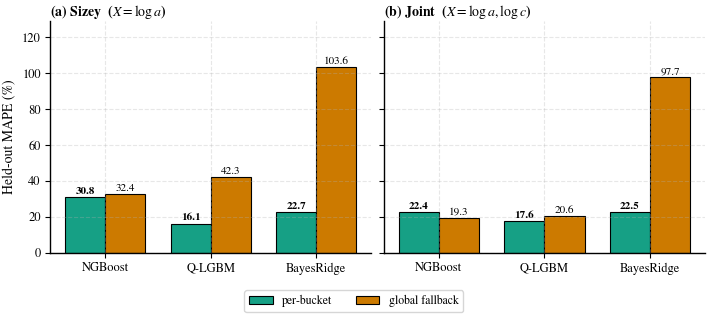

In [16]:
order = ["ngb", "qlgbm", "bayesridge"]
labels = ["NGBoost", "Q-LGBM", "BayesRidge"]

fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.8), sharey=True,
                           constrained_layout=True)
for ax, var, title in zip(axes, ["sizey", "joint"],
                           [r"(a) Sizey  ($X = \log a$)",
                            r"(b) Joint  ($X = \log a, \log c$)"]):
    bucket_vals = [metrics[metrics.model==f"{m}_{var}"].MAPE.iloc[0]        for m in order]
    global_vals = [metrics[metrics.model==f"{m}_global_{var}"].MAPE.iloc[0] for m in order]
    x = np.arange(len(order)); w = 0.38
    b1 = ax.bar(x - w/2, bucket_vals, w, label="per-bucket", color="#16a085",
                edgecolor="black", linewidth=0.8)
    b2 = ax.bar(x + w/2, global_vals, w, label="global fallback",
                color="#cc7a00", edgecolor="black", linewidth=0.8)
    finite_max = max([v for v in bucket_vals + global_vals if np.isfinite(v)] + [0])
    ax.set_ylim(0, finite_max * 1.32)
    for b, v in zip(b1, bucket_vals):
        if not np.isfinite(v): continue
        ax.text(b.get_x()+b.get_width()/2, v + finite_max*0.018, f"{v:.1f}",
                ha="center", fontsize=8, fontweight="bold")
    for b, v in zip(b2, global_vals):
        if not np.isfinite(v): continue
        ax.text(b.get_x()+b.get_width()/2, v + finite_max*0.018, f"{v:.1f}",
                ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    if var == "sizey": ax.set_ylabel("Held-out MAPE (%)")
    ax.set_title(title, loc="left", pad=4, fontweight="bold")

# Single legend below both panels
handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc="lower center", ncol=2, frameon=True,
           bbox_to_anchor=(0.5, -0.14))
save_figure(fig, "fig_e2_8_perbucket_vs_global"); plt.show()


## 12. Save fitted models

In [17]:
with open(OUT/"models_exp2.pkl", "wb") as f:
    pickle.dump({"per_bucket": trained, "global": global_fits}, f)
print(f"Wrote {OUT/'models_exp2.pkl'} ({(OUT/'models_exp2.pkl').stat().st_size:,} bytes)")
print(f"Wrote {OUT/'predictions_exp2.csv'}  ({(OUT/'predictions_exp2.csv').stat().st_size:,} bytes)")
print(f"Wrote {len(list(FIG.glob('fig_e2_*.png')))} figures into {FIG}")


Wrote C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\experiment_2\models_exp2.pkl (61,603,279 bytes)
Wrote C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\experiment_2\predictions_exp2.csv  (2,748,885 bytes)
Wrote 8 figures into C:\Users\govin\Downloads\IEEECLUSTER\IEEE_CLUSTER_MAIN\experiment_2\figures


## Summary

The output of this notebook is the **predictive-distribution table that the
gates of Experiment 3 will consume**:

- `pred_ngb_joint_MB` + `std_ngb_joint_MB` — Gate G1 input (predicted variance)
- `pred_ngb_joint_MB` + `std_ngb_joint_MB` + capacity → P(M > capacity) for Gate G2
- `proxy_pred_M_MB` — Gate G3 reference, with raw coefficients exposed so the
  caller can recompute the proxy on new tasks

We did **not** run any audit decisions in this notebook. Selecting which
incoming task instances to audit is the Experiment 3 question.
